# Simpson's paradox

Все мы любим отдыхать! А злые корпорации любят наживаться на нашем желании отдыхать.

Представим что вы работаете в одной из таких корпораций и занимаетесь аналитикой сайта для бронирования отелей. Процесс бронирования имеет привычную структуру:
- вбиваете в поиск направленния и даты
- получаете выдачу вариантов отелей
- переходите на страницу отеля
- нажимаете кнопку "забронировать"
- попадаете на страницу оплаты
- оплачиваете

Очевидно, на всех этапах этой воронки вы можете потерять пользователя. Поисследовав поведение пользователей вы решили внести изменения на странице об отеле и хотите чтобы выросла конверсия в бронирования

__а) [3 балла]__ Подумайте, какие изменения могли бы быть внесены?

**Ваш ответ:**

Перед вами датасет `ab_test.csv`, в нем содержатся данные о пользователях в период теста

`user_id` - уникальный идентификатор пользователя \
`sex` - пол пользователя \
`datetime` - дата и время посещения сайта (начала сессии) \
`district` - регион расположения отеля \
`hotel_page` - был ли пользователь на странице отеля в сессии \
`payment_page` - был ли пользователь на странице оплаты в сессии \
`payment` - была ли произведена оплата в сессии \
`group` - группа в эксперименте

Поскольку изменения вносились на странице отеля нас интересуют именно дошедшие до этой страницы пользователи. Поэтому колонка `hotel_page` принимает значение 1 всегда

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("ab_simpson.csv")
df.head()

,Unnamed: 0,user_id,sex,datetime,district,hotel_page,payment_page,payment,group
0,0,3326449108867616315,1,11/15/2023 12:02 AM,Южный федеральный округ,1,1,0,control
1,1,7887645543455909870,1,11/02/2023 09:12 PM,Центральный федеральный округ,1,1,0,control
2,2,6148146969124793824,1,11/10/2023 10:06 AM,Центральный федеральный округ,1,1,1,control
3,3,2721602951940155275,0,11/12/2023 07:10 PM,Центральный федеральный округ,1,1,0,control
4,4,1829030712785972138,0,05/01/2024 05:19 AM,Южный федеральный округ,1,0,0,test


In [4]:
df.shape

(401807, 9)

In [5]:
df.columns

Index(['Unnamed: 0', 'user_id', 'sex', 'datetime', 'district', 'hotel_page',
       'payment_page', 'payment', 'group'],
      dtype='str')

In [6]:
df.drop('Unnamed: 0', inplace=True, axis=1)

**б) [3 балла]** Сделайте небольшой eda, какие выводы вы можете сделать о данных? Корректно ли проводился аб тест? Найдите ошибки и объясните почему это некорректно.


In [7]:
df.dtypes

user_id         int64
sex             int64
datetime          str
district          str
hotel_page      int64
payment_page    int64
payment         int64
group             str
dtype: object

In [9]:
df['user_id'].nunique()
# некоторые пользователи посещали сайт несколько раз

401693

C:\Users\Gleb Gavrin\AppData\Local\Temp\ipykernel_135148\2193030771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


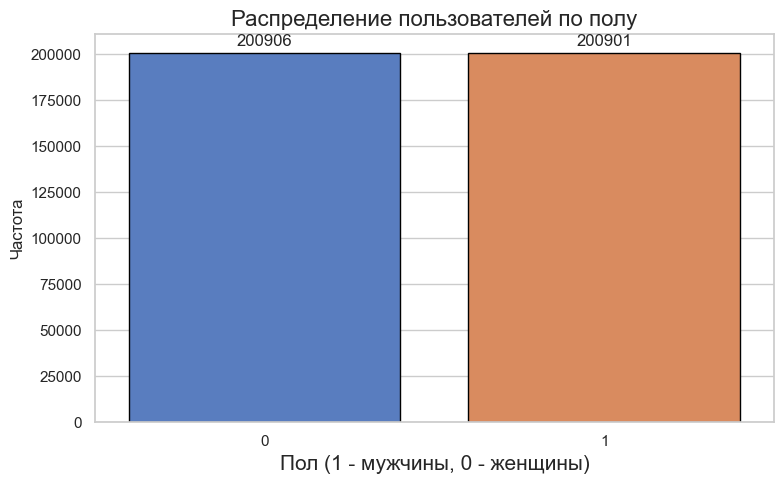

In [10]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df,
    x='sex',
    palette='muted', 
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title('Распределение пользователей по полу', fontsize=16)
plt.xlabel('Пол (1 - мужчины, 0 - женщины)', fontsize=15)
plt.ylabel('Частота', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Посмотрим, равномерно ли разбиты пользователи на тестовую и контрольную группы:

In [11]:
df['group'].value_counts(normalize=True)

group
test       0.502567
control    0.497433
Name: proportion, dtype: float64

Да, **тестовая и контрольная группа идентичны по размеру**. Теперь посмотрим детальнее на другие признаки:

In [12]:
df.describe()

,user_id,sex,hotel_page,payment_page,payment
count,4.018070e+05,401807.000000,401807.0,401807.000000,401807.000000
mean,4.615212e+18,0.499994,1.0,0.741824,0.292242
std,2.662886e+18,0.500001,0.0,0.437632,0.454794
min,5.888584e+13,0.000000,1.0,0.000000,0.000000
25%,2.309885e+18,0.000000,1.0,0.000000,0.000000
50%,4.610460e+18,0.000000,1.0,1.000000,0.000000
75%,6.923790e+18,1.000000,1.0,1.000000,1.000000
max,9.223335e+18,1.000000,1.0,1.000000,1.000000


In [13]:
df['district'].value_counts()

district
Южный федеральный округ              120749
Центральный федеральный округ        120336
Приволжский федеральный округ         60333
Северо-Западный федеральный округ     50071
Уральский федеральный округ           26189
Сибирский федеральный округ           16072
Дальневосточный федеральный округ      8057
Name: count, dtype: int64

In [14]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date

C:\Users\Gleb Gavrin\AppData\Local\Temp\ipykernel_135148\3608036409.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['datetime'])


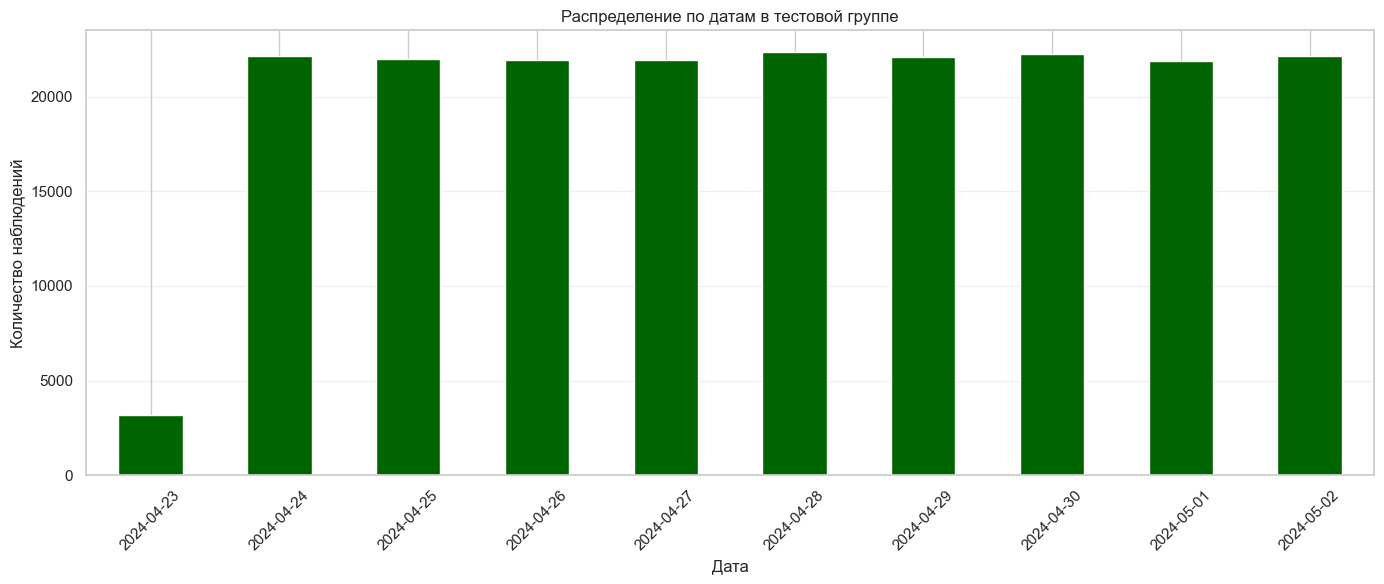

In [15]:
plt.figure(figsize=(14, 6))
df[df['group']=='test']['date'].value_counts().sort_index().plot(kind='bar', color='darkgreen')
plt.title('Распределение по датам в тестовой группе')
plt.xlabel('Дата')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

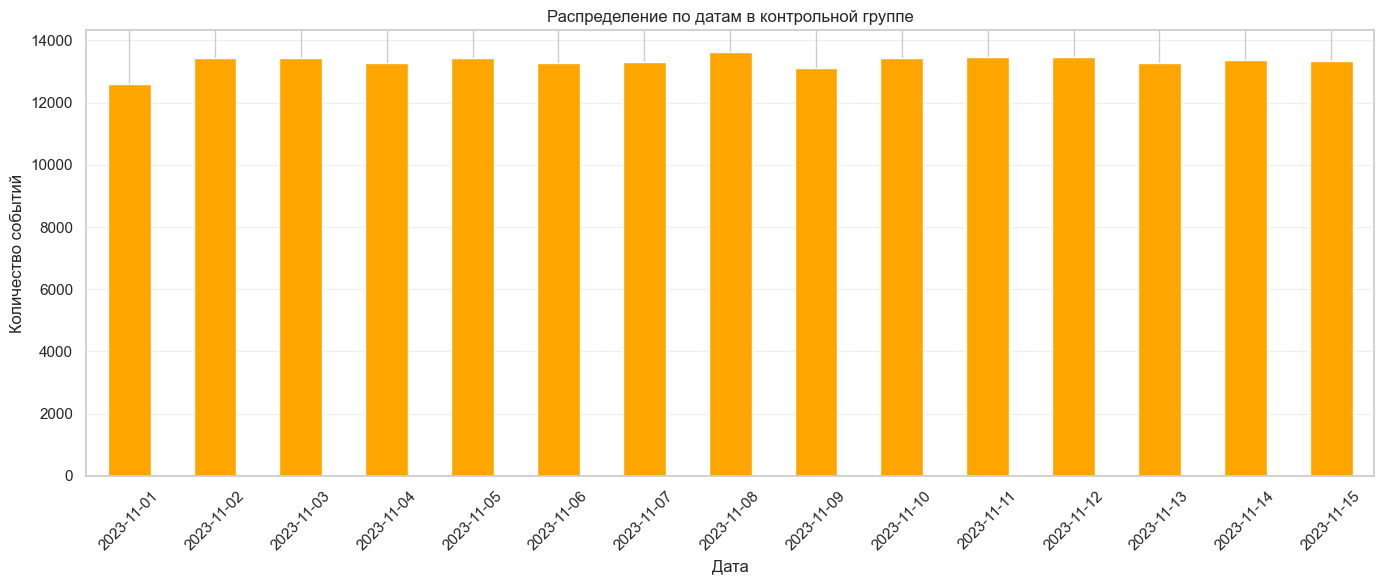

In [16]:
plt.figure(figsize=(14, 6))
df[df['group']=='control']['date'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Распределение по датам в контрольной группе')
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Для тестовой группы взяты наблюдения за 2024 год, а для контрольной за 2023. Это неправильно и противоречит теории АБ тестов. Нужно брать **параллельно наблюдения для тестовой и контрольной групп**

In [17]:
print("Распределение регионов в группах")
pd.crosstab(df['district'], df['group'], normalize='columns').round(2)

Распределение регионов в группах


group,control,test
district,,
Дальневосточный федеральный округ,0.01,0.03
Приволжский федеральный округ,0.12,0.18
Северо-Западный федеральный округ,0.20,0.05
Сибирский федеральный округ,0.04,0.04
Уральский федеральный округ,0.03,0.10
Центральный федеральный округ,0.40,0.20
Южный федеральный округ,0.20,0.40


Распределения не одинаковые между контролем и тестом, что ожидаемо из-за **временного лага**.\
Например, в Южном округе отдыхающих в апреле-мае существенно больше, чем в ноябре.\
**АБ тест проводился некорректно**, так как нарушен принцип случайного распределения, который лежит в основе теории АБ тестироавния

Раскроем правду. Изменение продукта касалось адаптации страницы отеля под его регион. Например, в южных регионах пользователям на странице отеля предлагались активности для пляжного отдыха, а в северном и центральном регионе сразу подбирались ближайшие экскурсии и так далее.

__в) [5 баллов]__ Проанализируйте, как ведут себя конверсии в страницу оплаты и в оплату в разных регионах? Опишите выводы.

In [18]:
regs = df.groupby('district').agg(users=('user_id', 'count'),
    payment_page=('payment_page', 'sum'),
    payment=('payment', 'sum'))

regs['CR_payment_page'] = round(regs['payment_page'] / regs['users'],2)
regs['CR_payment'] = round(regs['payment'] / regs['users'],2)

regs[['CR_payment_page','CR_payment']]

,CR_payment_page,CR_payment
district,,
Дальневосточный федеральный округ,0.18,0.31
Приволжский федеральный округ,0.63,0.30
Северо-Западный федеральный округ,0.70,0.27
Сибирский федеральный округ,0.31,0.29
Уральский федеральный округ,0.44,0.31
Центральный федеральный округ,0.91,0.28
Южный федеральный округ,0.81,0.31


In [19]:
df[(df['payment_page']==0) &(df['payment']==1)].shape

(30468, 9)

Меня удивляет наличие кейсов, когда **пользователь не был на странице оплаты, но оплатил**\
В целом, **конверсия в страницу оплаты очень разнится по регионам**. ЦФО и ЮФО - лидеры, при этом они в несколько раз опережают некоторые регионы\
При этом конверсия в оплату почти не отличается у разных регионов

In [20]:
reg_gr_CR = df.groupby(['district', 'group']).agg(
    users=('user_id', 'count'),
    payment_page=('payment_page', 'sum'),
    payment=('payment', 'sum')
).reset_index()

reg_gr_CR['CR_payment_page'] = reg_gr_CR['payment_page'] / reg_gr_CR['users']
reg_gr_CR['CR_payment'] = reg_gr_CR['payment'] / reg_gr_CR['users']

pivot = reg_gr_CR.pivot(index='district', columns='group', values=['CR_payment_page','CR_payment'])
print("\nСравнение конверсий в стр.оплаты и оплату по регионам")
pivot.round(2)


Сравнение конверсий в стр.оплаты и оплату по регионам


CR_payment_page       CR_payment      
group                                     control  test    control  test
district                                                                
Дальневосточный федеральный округ             0.1  0.20       0.23  0.33
Приволжский федеральный округ                 0.6  0.65       0.25  0.33
Северо-Западный федеральный округ             0.7  0.72       0.25  0.33
Сибирский федеральный округ                   0.3  0.32       0.25  0.33
Уральский федеральный округ                   0.4  0.45       0.24  0.33
Центральный федеральный округ                 0.9  0.93       0.25  0.33
Южный федеральный округ                       0.8  0.81       0.25  0.34

Заметим, что **в разбивке по регионам конверсия в страницу оплаты выросла в тесте по сравнению с контролем, как и конверсия в оплату**

__г) [5 баллов]__ Проанализируйте, улучшилась ли воронка для пользователей в тестовой группе по сравнению с контрольной вне зависимости от региона? Опишите выводы.

In [22]:
df.head()

,user_id,sex,datetime,district,hotel_page,payment_page,payment,group,date
0,3326449108867616315,1,2023-11-15 00:02:00,Южный федеральный округ,1,1,0,control,2023-11-15
1,7887645543455909870,1,2023-11-02 21:12:00,Центральный федеральный округ,1,1,0,control,2023-11-02
2,6148146969124793824,1,2023-11-10 10:06:00,Центральный федеральный округ,1,1,1,control,2023-11-10
3,2721602951940155275,0,2023-11-12 19:10:00,Центральный федеральный округ,1,1,0,control,2023-11-12
4,1829030712785972138,0,2024-05-01 05:19:00,Южный федеральный округ,1,0,0,test,2024-05-01


In [23]:
gr = df.groupby('group').agg(users=('user_id', 'count'),
    payment_page=('payment_page', 'sum'),
    payment=('payment', 'sum'))

gr['CR_payment_page'] = round(gr['payment_page'] / gr['users'],2)
gr['CR_payment'] = round(gr['payment'] / gr['users'],2)

gr[['users', 'CR_payment_page', 'CR_payment']]

,users,CR_payment_page,CR_payment
group,,,
control,199872,0.76,0.25
test,201935,0.73,0.33


Воронка в тестовой группе улучшилась с точки зрения перехода к оплате, но ухудшилась с точки зрения перехода на страницу оплаты.\
Насколько я понял, в данной задаче целевой метрикой являлась конверсия в страницу оплаты, поэтому **эффект скорее отрицательный**

__д) [5 баллов]__ Проанализируйте распределение интересов пользователей в тестовой и контрольной группе. Какими регионами они интересовались? Изменились ли их предпочтения?

In [24]:
x = pd.crosstab(df['district'], df['group'], normalize='columns')
x['diff'] = x['test'] - x['control']
x.round(2)

group,control,test,diff
district,,,
Дальневосточный федеральный округ,0.01,0.03,0.02
Приволжский федеральный округ,0.12,0.18,0.06
Северо-Западный федеральный округ,0.20,0.05,-0.15
Сибирский федеральный округ,0.04,0.04,0.00
Уральский федеральный округ,0.03,0.10,0.07
Центральный федеральный округ,0.40,0.20,-0.20
Южный федеральный округ,0.20,0.40,0.20


**Предпочтения пользователей в тесте и контроле совершенно разные**, я связываю это с временным лагом между группами

Если вы все сделали правильно, то у вас получился противоречивые ответы в пунктах 3 и 4. Вы попали в ловушку Парадокса Симпсона. Подробнее о нем можно почитать [здесь](https://ru.wikipedia.org/wiki/Парадокс_Симпсона)

<img src="https://github.com/hse-econ-data-science/andan_2023/blob/main/hw/hw04/images/simpson.jpg?raw=true" width="350" align='center'> 

__е) [4 балла]__ Теперь, когда вы все узнали, опишите кратко почему вы получили противоречивый результат в пунктах 3 и 4 (1 балл)

**Ваш ответ:** противоречивый результат состоит в том, что конверсия в страницу оплаты растет в разбивке по регионам, но падает, если рассматривать суммарно.\
Парадокс Симпсона как раз состоит в том, что в разбивке по группам наблюдается одинаково направленная зависимость, при объединении этих групп направление зависимости меняется на противоположное.\
Происходит из-за того, что был лаг времени между группами и сменилось распределение интересов пользователей в регионах отдыха (весна vs ноябрь)\
Хоть конверсия в регионах улучшилась, но произошло смещение выборки в сторону регионов с меньшей конверсией в переход на стр. оплаты, поэтому общая конверсия в тесте стала меньше.\
было 40% ЦФО, 20% ЮФО, 20% СЗФО, 12% ПФО, ...\
стало 40% ЮФО, 20% ЦФО, 18% ПФО, 5% СЗФО, ...\
конверсия в стр. оплаты: ЦФО > ЮФО > СЗФО > ПФО...\
выборка сместилась в сторону регионов с более низкой, в целом, конверсией в переход на стр. оплаты